### Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from copy import deepcopy

### Load your data

In [2]:
# Paths 
pos_path = "datasets/DDI_positive_pairs.csv"
neg_path = "datasets/DDI_negative_pairs.csv"
emb_dir = "datasets"
graph_path = "networks/simon_network.graphml"

# Load drug embeddings (MeSH-based)
emb_df = pd.read_csv(f"{emb_dir}/MeSH_mid_level_tfidf_svd128.csv", index_col=0)

# Load positive/negative pairs
pos = pd.read_csv(pos_path)
neg = pd.read_csv(neg_path)

# Match column names to your loader format
pos["label"] = 1
neg["label"] = 0

pairs = pd.concat([pos, neg], ignore_index=True)

# Convert to string drug IDs (very important!)
pairs["drug1"] = pairs["drug1"].astype(str)
pairs["drug2"] = pairs["drug2"].astype(str)

print(pairs.head())

     drug1    drug2  label
0  DB00001  DB06605      1
1  DB00001  DB06695      1
2  DB00001  DB01254      1
3  DB00001  DB01609      1
4  DB00001  DB01586      1


### Train/test/val split --> DOWNSAMPLING NEEDED

In [3]:
### DOWNSAMPLING to balance classes
pos = pos.sample(n=len(neg), random_state=42)   # downsample positives to match negatives
pairs = pd.concat([pos, neg], ignore_index=True)

pairs["drug1"] = pairs["drug1"].astype(str)
pairs["drug2"] = pairs["drug2"].astype(str)

### Train/test/val split
train_val_df, test_df = train_test_split(
    pairs,
    test_size=0.10,
    random_state=42,
    shuffle=True,
    stratify=pairs["label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.10,
    random_state=42,
    shuffle=True,
    stratify=train_val_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

8937 993 1104


### Compute Topo Feats

In [4]:
from TopoFeatExtractor import TopoFeatExtractor

# Initialize extractor
topo_extractor = TopoFeatExtractor(
    graph_path,
    use_betweenness=False,
    use_protein_neighborhood=False,
    protein_feat_path=None,
    use_weighted=False
)

# Collect all drugs across splits
all_drugs = list(
    set(train_df["drug1"]) | set(train_df["drug2"]) |
    set(val_df["drug1"])   | set(val_df["drug2"])   |
    set(test_df["drug1"])  | set(test_df["drug2"])
)

# Remove ALL held-out edges (val + test)
edges_to_remove = pd.concat([val_df, test_df], ignore_index=True)

# Compute fold-specific topological features
topo_df = (
    topo_extractor
    .compute_for_fold(drug_ids=all_drugs, eval_pairs=edges_to_remove)
    .reindex(all_drugs)
    .fillna(0)
)

topo_df.head()

   Graph loaded: 17976 nodes, 268307 edges
   Found 3263 drug nodes.

Removing 1048 eval DDI edges for leakage safety.
Computing topological features for 2109 drugs...
→ Processed 500/2109 drugs (11.5s elapsed)
→ Processed 1000/2109 drugs (25.3s elapsed)
→ Processed 1500/2109 drugs (39.2s elapsed)
→ Processed 2000/2109 drugs (54.1s elapsed)
Finished 2109 drugs in 57.2s total.
Computed features for 2109 drugs.


,deg_total,deg_drug,deg_prot,deg_min,deg_max,deg_mean,deg_std,clust_local,boundary_ratio,close_local,katz_local,n_nodes_subgraph
drugbank_id,,,,,,,,,,,,
DB14509,7,0,7,19,307,64.428571,99.176404,0.190476,104.685930,0.000000,0.047881,398
DB00650,1,0,1,138,138,138.000000,0.000000,0.000000,14.496403,0.501818,0.084264,139
DB01396,8,0,8,11,913,351.375000,310.095928,0.000000,35.498235,0.000000,0.024730,1700
DB01394,8,0,8,149,913,428.000000,241.540369,0.000000,42.741883,0.000000,0.023310,1848
DB00991,2,0,2,109,132,120.500000,11.500000,1.000000,68.678571,0.503012,0.076283,168


### STANDARDIZATION — Fit on TRAIN, freeze, apply everywhere

In [5]:
### STANDARDIZATION OF TOPO FEATURES
from sklearn.preprocessing import StandardScaler

train_drugs = list(set(train_df["drug1"]) | set(train_df["drug2"]))
scaler_topo = StandardScaler()
scaler_topo.fit(topo_df.loc[train_drugs])

topo_df = pd.DataFrame(
    scaler_topo.transform(topo_df),
    index=topo_df.index,
    columns=topo_df.columns
)

### Import & Init Models

In [6]:
from LatentGateModel import LatentGateModel
from TopoAblation import TopoOnlyModel

fusion_model = LatentGateModel(
    bio_dim=128,
    topo_dim=topo_df.shape[1],
    gate_scalar=False
)

topo_model = TopoOnlyModel(
    topo_dim=topo_df.shape[1]
)

init gate_scalar:  False


### Trainer Function for Fusion w Early Stopping

In [7]:
def train_fusion_simple(
    model, train_df, emb_df, topo_df,
    scaler_topo,
    scaler_bio=None,
    max_epochs=30, patience=5
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    topo_dict = topo_df.to_dict(orient="index")
    emb_dict  = emb_df.to_dict(orient="index")

    bio_dim  = emb_df.shape[1]
    topo_dim = topo_df.shape[1]
    emb_cols = list(emb_df.columns)
    topo_cols = list(topo_df.columns)

    # feature getters ---------------------------------------------------------
    def get_topo(drug):
        if drug not in topo_dict:
            x = np.zeros(topo_dim)
        else:
            x = np.array([topo_dict[drug][c] for c in topo_cols])

        # Pass as DataFrame to match feature names
        x_df = pd.DataFrame([x], columns=topo_cols)
        return scaler_topo.transform(x_df).flatten()

    def get_bio(drug):
        if drug not in emb_dict:
            vec = np.zeros(bio_dim)
        else:
            vec = np.array([emb_dict[drug][c] for c in emb_cols])
        if scaler_bio is not None:
            vec = scaler_bio.transform([vec]).flatten()
        return vec

    # optimizer ---------------------------------------------------------------
    opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    crit = nn.BCEWithLogitsLoss()

    best_loss = float("inf")
    best_state = None
    patience_counter = 0

    # training loop -----------------------------------------------------------
    for epoch in range(max_epochs):
        model.train()
        losses = []

        for _, row in train_df.iterrows():
            d1, d2, y = row["drug1"], row["drug2"], row["label"]

            bio1 = torch.tensor(get_bio(d1), dtype=torch.float32).unsqueeze(0).to(device)
            bio2 = torch.tensor(get_bio(d2), dtype=torch.float32).unsqueeze(0).to(device)
            t1   = torch.tensor(get_topo(d1), dtype=torch.float32).unsqueeze(0).to(device)
            t2   = torch.tensor(get_topo(d2), dtype=torch.float32).unsqueeze(0).to(device)
            yb   = torch.tensor([y], dtype=torch.float32).to(device)

            opt.zero_grad()
            logit, _ = model(bio1, t1, bio2, t2)
            loss = crit(logit, yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        mean_loss = np.mean(losses)
        print(f"[Fusion] Epoch {epoch+1:02d} loss={mean_loss:.4f}")

        if mean_loss < best_loss:
            best_loss = mean_loss
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("[Fusion] Early stopping!")
                break

    model.load_state_dict(best_state)
    return model

### Trainer Function for Topo-Only Classifier w/ Early Stopping

In [8]:
def train_topo_only_simple(
    model, train_df, topo_df, scaler_topo,
    max_epochs=30, patience=5
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    topo_dict = topo_df.to_dict(orient="index")
    topo_dim = topo_df.shape[1]
    cols = list(topo_df.columns)

    def get_t(drug):
        if drug not in topo_dict:
            x = np.zeros(topo_dim)
        else:
            x = np.array([topo_dict[drug][c] for c in cols])

        x_df = pd.DataFrame([x], columns=cols)
        return scaler_topo.transform(x_df).flatten()

    opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    crit = nn.BCEWithLogitsLoss()

    best_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        losses = []
        for _, row in train_df.iterrows():
            d1, d2, y = row["drug1"], row["drug2"], row["label"]

            t1 = torch.tensor(get_t(d1), dtype=torch.float32).unsqueeze(0).to(device)
            t2 = torch.tensor(get_t(d2), dtype=torch.float32).unsqueeze(0).to(device)
            yb = torch.tensor([y], dtype=torch.float32).to(device)

            opt.zero_grad()
            logit = model(t1, t2)
            loss = crit(logit, yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        mean_loss = np.mean(losses)
        print(f"[TopoOnly] Epoch {epoch+1:02d} loss={mean_loss:.4f}")

        if mean_loss < best_loss:
            best_loss = mean_loss
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("[TopoOnly] Early stopping!")
                break

    model.load_state_dict(best_state)
    return model

### Train Models

In [9]:
fusion_trained = train_fusion_simple(
    fusion_model,
    train_df,
    emb_df,
    topo_df,
    scaler_topo=scaler_topo
)

topo_only_trained = train_topo_only_simple(
    topo_model,
    train_df,
    topo_df,
    scaler_topo=scaler_topo
)

[Fusion] Epoch 01 loss=0.3827
[Fusion] Epoch 02 loss=0.2615
[Fusion] Epoch 03 loss=0.2124
[Fusion] Epoch 04 loss=0.1869
[Fusion] Epoch 05 loss=0.1663
[Fusion] Epoch 06 loss=0.1530
[Fusion] Epoch 07 loss=0.1379
[Fusion] Epoch 08 loss=0.1344
[Fusion] Epoch 09 loss=0.1245
[Fusion] Epoch 10 loss=0.1201
[Fusion] Epoch 11 loss=0.1123
[Fusion] Epoch 12 loss=0.1095
[Fusion] Epoch 13 loss=0.1055
[Fusion] Epoch 14 loss=0.1048
[Fusion] Epoch 15 loss=0.0985
[Fusion] Epoch 16 loss=0.0931
[Fusion] Epoch 17 loss=0.0958
[Fusion] Epoch 18 loss=0.0909
[Fusion] Epoch 19 loss=0.0893
[Fusion] Epoch 20 loss=0.0903
[Fusion] Epoch 21 loss=0.0861
[Fusion] Epoch 22 loss=0.0813
[Fusion] Epoch 23 loss=0.0800
[Fusion] Epoch 24 loss=0.0824
[Fusion] Epoch 25 loss=0.0770
[Fusion] Epoch 26 loss=0.0750
[Fusion] Epoch 27 loss=0.0792
[Fusion] Epoch 28 loss=0.0686
[Fusion] Epoch 29 loss=0.0665
[Fusion] Epoch 30 loss=0.0699
[TopoOnly] Epoch 01 loss=0.6828
[TopoOnly] Epoch 02 loss=0.6757
[TopoOnly] Epoch 03 loss=0.6748
[Top

### Get Preds

In [10]:
def predict_fusion(model, df, emb_df, topo_df, scaler_topo, scaler_bio=None):
    model.eval()
    device = next(model.parameters()).device

    topo_dict = topo_df.to_dict(orient="index")
    emb_dict  = emb_df.to_dict(orient="index")

    bio_dim  = emb_df.shape[1]
    topo_dim = topo_df.shape[1]
    emb_cols = list(emb_df.columns)
    topo_cols = list(topo_df.columns)

    scores = []

    def get_topo(drug):
        if drug not in topo_dict:
            x = np.zeros(topo_dim)
        else:
            x = np.array([topo_dict[drug][c] for c in topo_cols])

        # Pass as DataFrame to match feature names
        x_df = pd.DataFrame([x], columns=topo_cols)
        return scaler_topo.transform(x_df).flatten()

    def get_bio(drug):
        if drug not in emb_dict:
            v = np.zeros(bio_dim)
        else:
            v = np.array([emb_dict[drug][c] for c in emb_cols])
        if scaler_bio is not None:
            v = scaler_bio.transform([v]).flatten()
        return v

    with torch.no_grad():
        for _, row in df.iterrows():
            d1, d2 = row["drug1"], row["drug2"]

            bio1 = torch.tensor(get_bio(d1), dtype=torch.float32).unsqueeze(0).to(device)
            bio2 = torch.tensor(get_bio(d2), dtype=torch.float32).unsqueeze(0).to(device)
            t1   = torch.tensor(get_topo(d1), dtype=torch.float32).unsqueeze(0).to(device)
            t2   = torch.tensor(get_topo(d2), dtype=torch.float32).unsqueeze(0).to(device)

            logit, _ = model(bio1, t1, bio2, t2)
            score = torch.sigmoid(logit).item()

            scores.append(score)

    df = df.copy()
    df["score"] = scores
    return df

In [11]:
def predict_topo_only(model, df, topo_df, scaler_topo):
    model.eval()
    device = next(model.parameters()).device

    topo_dict = topo_df.to_dict(orient="index")
    topo_dim = topo_df.shape[1]
    cols = list(topo_df.columns)

    def get_t(drug):
        if drug not in topo_dict:
            x = np.zeros(topo_dim)
        else:
            x = np.array([topo_dict[drug][c] for c in cols])

        x_df = pd.DataFrame([x], columns=cols)
        return scaler_topo.transform(x_df).flatten()

    scores = []

    with torch.no_grad():
        for _, row in df.iterrows():
            d1, d2 = row["drug1"], row["drug2"]

            t1 = torch.tensor(get_t(d1), dtype=torch.float32).unsqueeze(0).to(device)
            t2 = torch.tensor(get_t(d2), dtype=torch.float32).unsqueeze(0).to(device)

            score = torch.sigmoid(model(t1, t2)).item()
            scores.append(score)

    df = df.copy()
    df["score"] = scores
    return df

In [12]:
fusion_preds = predict_fusion(
    fusion_trained, 
    test_df, 
    emb_df, 
    topo_df,
    scaler_topo=scaler_topo
)


top5_pos_fusion = fusion_preds.sort_values("score", ascending=False).head(5)
top5_neg_fusion = fusion_preds.sort_values("score", ascending=True).head(5)

top5_pos_fusion, top5_neg_fusion

(        drug1    drug2  label  score
 1103  DB06674  DB00203      1    1.0
 201   DB05676  DB09301      1    1.0
 601   DB09098  DB00575      1    1.0
 207   DB01028  DB01014      1    1.0
 607   DB00503  DB09079      1    1.0,
        drug1    drug2  label         score
 674  DB00529  DB01188      0  5.998575e-17
 362  DB00529  DB06151      0  1.423202e-15
 542  DB01019  DB00419      0  2.735602e-15
 429  DB00419  DB00859      0  3.550099e-15
 745  DB00419  DB02530      0  6.959963e-15)

In [13]:
topo_preds = predict_topo_only(
    topo_only_trained,
    test_df,
    topo_df,
    scaler_topo=scaler_topo
)


top5_pos_topo = topo_preds.sort_values("score", ascending=False).head(5)
top5_neg_topo = topo_preds.sort_values("score", ascending=True).head(5)

top5_pos_topo, top5_neg_topo

(        drug1    drug2  label  score
 925   DB06822  DB09214      1    1.0
 557   DB08893  DB01419      1    1.0
 488   DB08935  DB12698      1    1.0
 1047  DB04829  DB09101      1    1.0
 684   DB08970  DB01600      1    1.0,
        drug1    drug2  label     score
 685  DB00593  DB02530      0  0.040956
 819  DB00809  DB00513      0  0.102942
 956  DB06154  DB01394      1  0.130064
 456  DB06154  DB00493      1  0.141946
 521  DB08904  DB01050      1  0.147715)

### Visualize

In [15]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def visualize_drug_protein_neighborhood(
    G,
    drug_a,
    drug_b,
    hops=2,
    max_nodes=100,
    figsize=(12, 10)
):
    """
    Visualize full connected 2-hop protein neighborhoods:
    - includes Target (T), intermediate proteins (P1), and 2-hop proteins (P2)
    - intersection proteins highlighted in red
    - drug-specific colors preserved
    """

    def get_targets(drug):
        return {
            nbr for nbr in G.neighbors(drug)
            if G.nodes[nbr].get("type", "").lower() == "target"
        }

    def get_full_2hop(drug):
        """
        Return:
        - targets directly connected to drug
        - all proteins at <=2 hops INCLUDING intermediate proteins
        """
        targets = get_targets(drug)
        full = set(targets)

        for t in targets:
            # BFS with hops=2 returns ALL nodes in the 2-hop sphere
            for node, dist in nx.single_source_shortest_path_length(G, t, cutoff=hops).items():
                if G.nodes[node].get("type", "").lower() == "protein":
                    full.add(node)

        return targets, full

    # Get both neighborhoods
    targets_a, neigh_a = get_full_2hop(drug_a)
    targets_b, neigh_b = get_full_2hop(drug_b)

    # intersection
    intersect = neigh_a & neigh_b

    # Limit the displayed nodes if huge
    def reduce_set(s):
        if len(s) > max_nodes:
            return set(list(s)[:max_nodes])
        return s

    neigh_a = reduce_set(neigh_a)
    neigh_b = reduce_set(neigh_b)

    # Build full subgraph (with intermediates!)
    node_set = {drug_a, drug_b} | neigh_a | neigh_b
    subG = G.subgraph(node_set).copy()

    # ----- Colors -----
    def rgba(hex_color, alpha):
        h = hex_color.lstrip('#')
        rgb = tuple(int(h[i:i+2], 16) / 255 for i in (0,2,4))
        return (*rgb, alpha)

    color_a = "#1f77b4"
    color_b = "#ff7f0e"
    color_intersect = "#d62728"

    node_color_map = {}
    node_sizes = {}

    for n in subG.nodes():
        if n == drug_a:
            node_color_map[n] = color_a
            node_sizes[n] = 900
        elif n == drug_b:
            node_color_map[n] = color_b
            node_sizes[n] = 900
        elif n in intersect:
            node_color_map[n] = color_intersect
            node_sizes[n] = 550
        elif n in targets_a:
            node_color_map[n] = rgba(color_a, 0.85)
            node_sizes[n] = 380
        elif n in targets_b:
            node_color_map[n] = rgba(color_b, 0.85)
            node_sizes[n] = 380
        elif n in neigh_a:
            node_color_map[n] = rgba(color_a, 0.45)
            node_sizes[n] = 250
        elif n in neigh_b:
            node_color_map[n] = rgba(color_b, 0.45)
            node_sizes[n] = 250
        else:
            node_color_map[n] = "#cccccc"
            node_sizes[n] = 200

    # ----- Draw -----
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(subG, seed=42, k=0.28)

    nx.draw_networkx_nodes(
        subG,
        pos,
        node_color=[node_color_map[n] for n in subG.nodes()],
        node_size=[node_sizes[n] for n in subG.nodes()],
        linewidths=0.3,
        edgecolors="black"
    )

    nx.draw_networkx_edges(subG, pos, alpha=0.3)

    important = {
        n: n for n in ({drug_a, drug_b} | intersect)
        if n in subG.nodes
    }

    nx.draw_networkx_labels(subG, pos, labels=important, font_size=9)

    plt.title(
        f"Protein Neighborhoods of {drug_a} and {drug_b}\n"
        "Including Full 2-Hop Connectivity (Intermediate Proteins Preserved)"
    )
    plt.axis("off")
    plt.show()

In [7]:
graph_path = "networks/unweighted_dppi_PubMedBERT.graphml"
G = nx.read_graphml(graph_path)

Candidate drugs:

(        drug1    drug2  label  score
 925   DB06822  DB09214      1    1.0
 557   DB08893  DB01419      1    1.0
 488   DB08935  DB12698      1    1.0
 1047  DB04829  DB09101      1    1.0
 684   DB08970  DB01600      1    1.0,
        drug1    drug2  label     score
 685  DB00593  DB02530      0  0.040956
 819  DB00809  DB00513      0  0.102942
 956  DB06154  DB01394      1  0.130064
 456  DB06154  DB00493      1  0.141946
 521  DB08904  DB01050      1  0.147715)

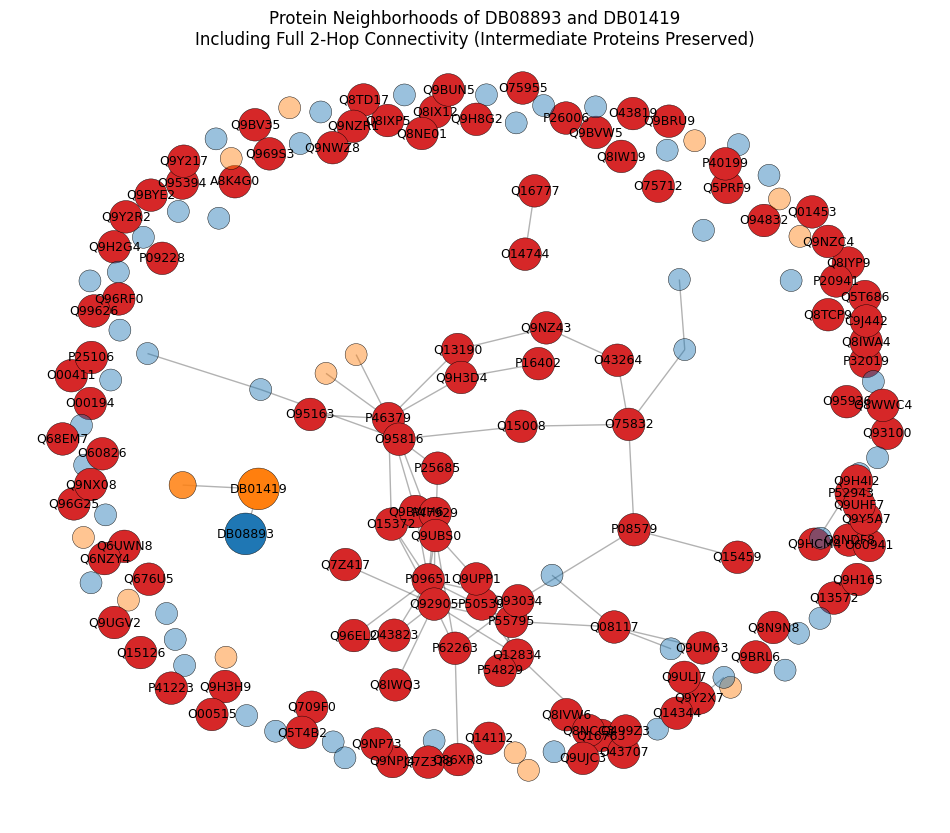

In [16]:
visualize_drug_protein_neighborhood(
    G=G,
    drug_a="DB08893",
    drug_b="DB01419"
)

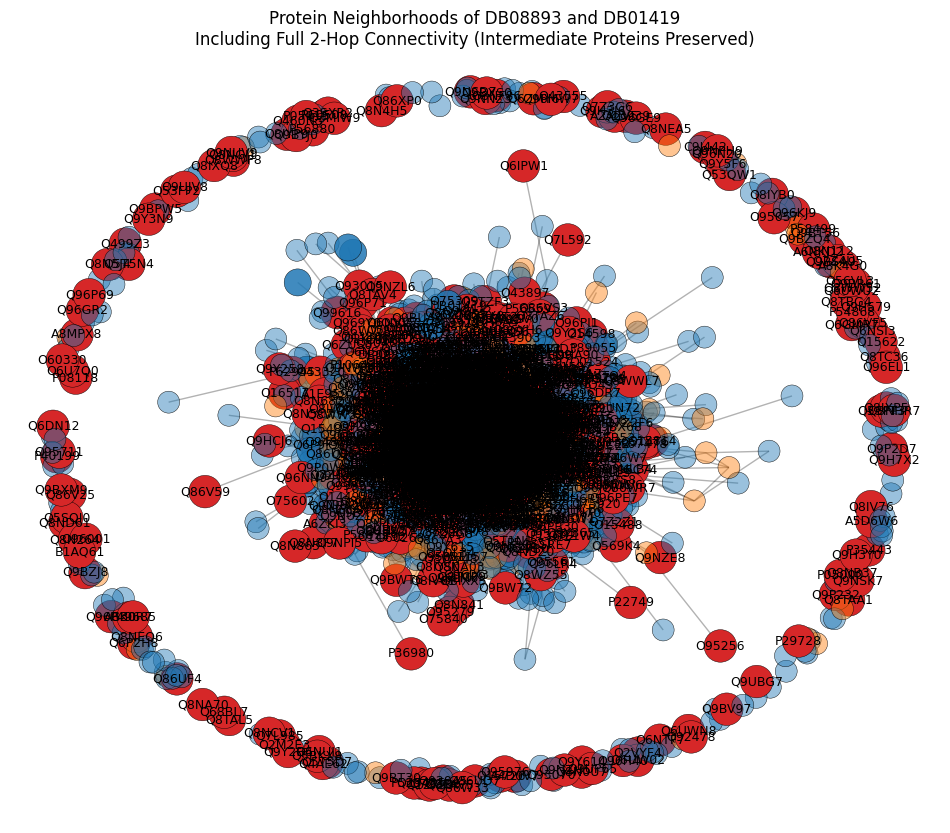

In [12]:
visualize_drug_protein_neighborhood(
    G=G,
    drug_a="DB08893",
    drug_b="DB01419"
)

In [ ]:
def check_drug_edges(G, drug, verbose=True):
    nbrs = list(G.neighbors(drug))
    if verbose:
        print(f"{drug} neighbors ({len(nbrs)}):")
        for n in nbrs:
            print("  ", n, G.nodes[n].get("type"))
    return nbrs

# Example
check_drug_edges(G, "DB08893")
check_drug_edges(G, "DB01419")

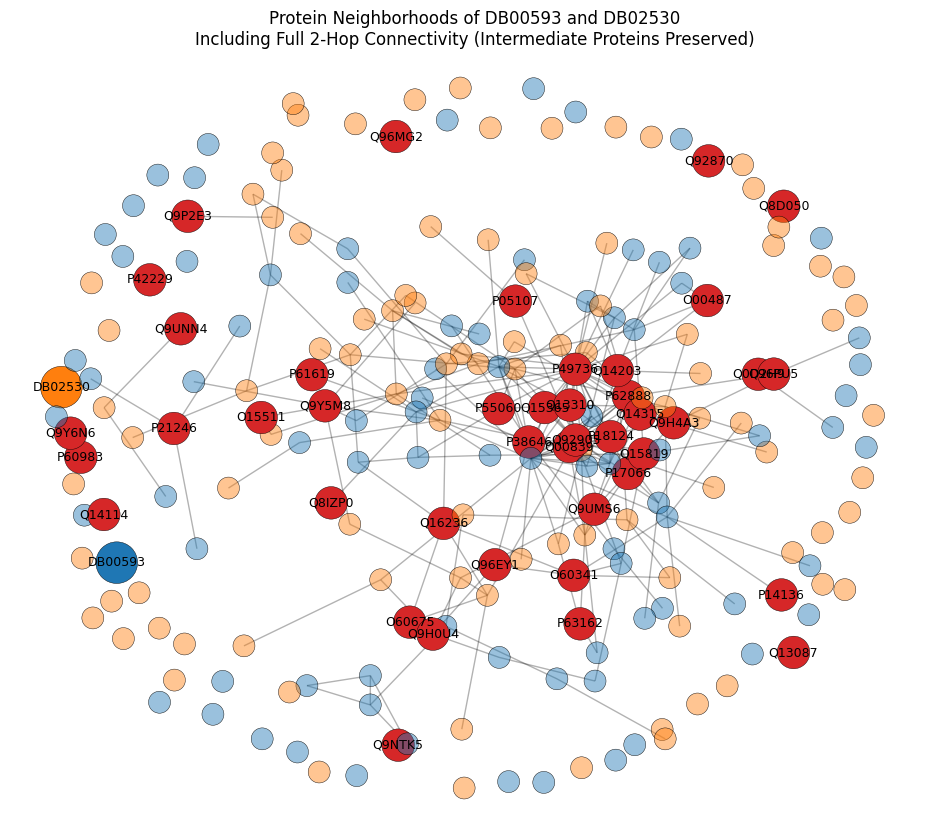

In [32]:
visualize_drug_protein_neighborhood(
    G=G,
    drug_a="DB00593",
    drug_b="DB02530"
)